# Lab 2 - Análise Comparativa dos Modelos

Comparação de desempenho de todos os classificadores treinados nos notebooks 2A, 2B e 2C.
Métricas: Acurácia, Precision, Recall, F1-Score e Kappa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lab2_utils import buscar_melhores_runs

Iniciando servidor MLflow em background...


Servidor MLflow pronto em http://127.0.0.1:5000


## Carregamento das Métricas via MLflow

A função `buscar_melhores_runs()` do `lab2_utils.py` busca todos os runs finalizados
do experimento `Lab2-Churn` e deduplica automaticamente — mantém apenas o run mais
recente de cada modelo, ordenado por F1-Score.

In [2]:
df_metricas = buscar_melhores_runs()

print(f'Total de modelos registrados: {len(df_metricas)}')
df_metricas

Total de modelos registrados: 3


,Acuracia,Precision,Recall,F1-Score,Kappa
Modelo,,,,,
MLP,0.521686,0.497564,0.998065,0.664070,0.086650
RandomForest,0.521593,0.497515,0.998065,0.664027,0.086481
DecisionTree,0.521593,0.497515,0.998065,0.664027,0.086481


## Comparação de Métricas

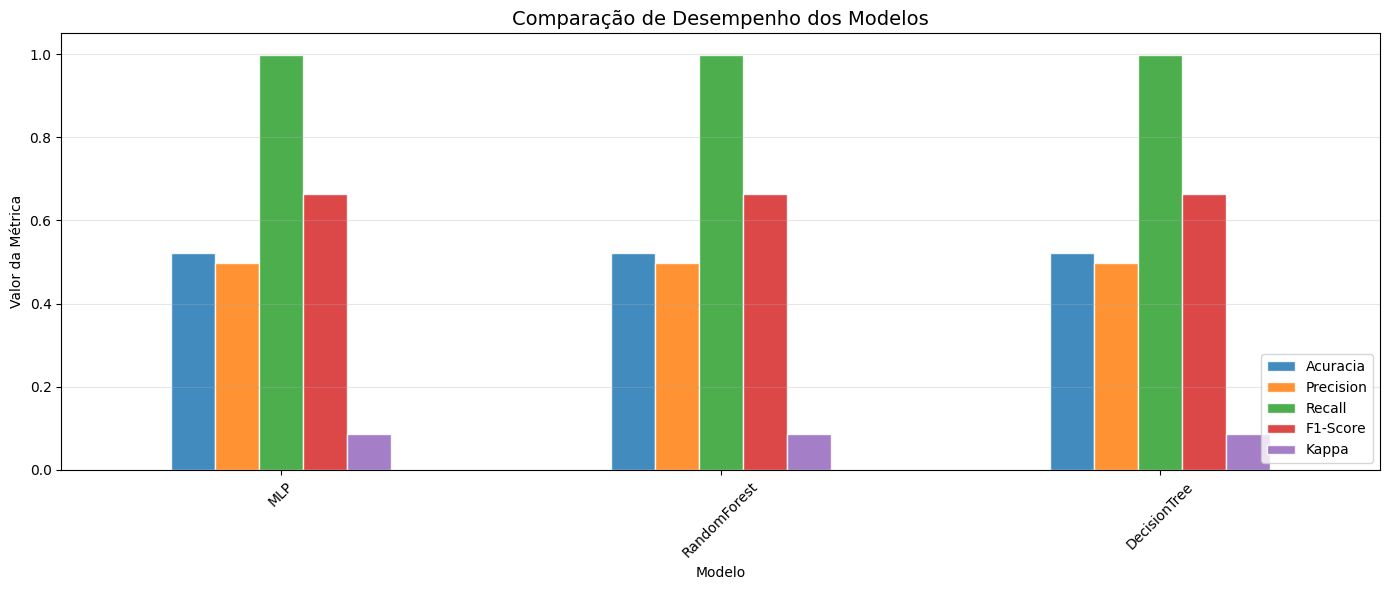

In [3]:
metricas_cols = ['Acuracia', 'Precision', 'Recall', 'F1-Score', 'Kappa']

fig, ax = plt.subplots(figsize=(14, 6))

df_metricas[metricas_cols].plot.bar(ax=ax, edgecolor='white', alpha=0.85)
ax.set_title('Comparação de Desempenho dos Modelos', fontsize=14)
ax.set_ylabel('Valor da Métrica')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../relatorio/imagens/3_comp_barplot_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## Ranking dos Modelos

In [4]:
print('=== Ranking por F1-Score ===')
print(df_metricas.sort_values('F1-Score', ascending=False)[metricas_cols].to_string())

print('\n=== Ranking por Kappa ===')
print(df_metricas.sort_values('Kappa', ascending=False)[metricas_cols].to_string())

=== Ranking por F1-Score ===
              Acuracia  Precision    Recall  F1-Score     Kappa
Modelo                                                         
MLP           0.521686   0.497564  0.998065  0.664070  0.086650
RandomForest  0.521593   0.497515  0.998065  0.664027  0.086481
DecisionTree  0.521593   0.497515  0.998065  0.664027  0.086481

=== Ranking por Kappa ===
              Acuracia  Precision    Recall  F1-Score     Kappa
Modelo                                                         
MLP           0.521686   0.497564  0.998065  0.664070  0.086650
RandomForest  0.521593   0.497515  0.998065  0.664027  0.086481
DecisionTree  0.521593   0.497515  0.998065  0.664027  0.086481
